In [1]:
import os
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
SEED = 2912

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
torch.backends.cudnn.benchmark = True

In [4]:
DATASET_PATH = "../Dataset"
DATASET_NAME = "Mendeley_Dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-4
ACCUM_STEPS = 2
PATIENCE = 15
MIN_DELTA = 0.001

OUTPUT_DIR = f"../Results/{DATASET_NAME}/Model_1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 0.8)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [7]:
full_dataset = datasets.ImageFolder(f"{DATASET_PATH}/{DATASET_NAME}")

class_names = full_dataset.classes
num_classes = len(class_names)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(class_names)
print(num_classes)

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
7


In [23]:
class ParallelLightCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Sequential(
            nn.Linear(64,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.6)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(64,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.6)
        )

        self.classifier = nn.Linear(256,num_classes)

    def forward(self,x):
        x = self.features(x)
        x = self.gap(x).flatten(1)

        b1 = self.fc1(x)
        b2 = self.fc2(x)

        x = torch.cat([b1,b2],dim=1)

        return self.classifier(x)

model = ParallelLightCNN(num_classes).to(device)

params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")

Parameters: 38,535


In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3
)

scaler = GradScaler()

In [28]:
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return total_loss/len(loader), acc, all_labels, all_preds

In [29]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_acc = 0
best_weights = copy.deepcopy(model.state_dict())
early_counter = 0

In [30]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    optimizer.zero_grad()

    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)

        with autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (i+1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item()*ACCUM_STEPS

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc + MIN_DELTA:
        best_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, f"{OUTPUT_DIR}/best_model.pth")
        early_counter = 0
    else:
        early_counter += 1

    if early_counter >= PATIENCE:
        print("Early stopping")
        break

Epoch 1/100
Train Acc: 0.3130 | Val Acc: 0.4042
Epoch 2/100
Train Acc: 0.3703 | Val Acc: 0.4140
Epoch 3/100
Train Acc: 0.3846 | Val Acc: 0.4221
Epoch 4/100
Train Acc: 0.3911 | Val Acc: 0.4302
Epoch 5/100
Train Acc: 0.4134 | Val Acc: 0.4562
Epoch 6/100
Train Acc: 0.4370 | Val Acc: 0.4627
Epoch 7/100
Train Acc: 0.4199 | Val Acc: 0.4659
Epoch 8/100
Train Acc: 0.4272 | Val Acc: 0.4724
Epoch 9/100
Train Acc: 0.4407 | Val Acc: 0.4789
Epoch 10/100
Train Acc: 0.4476 | Val Acc: 0.4854
Epoch 11/100
Train Acc: 0.4602 | Val Acc: 0.4838
Epoch 12/100
Train Acc: 0.4606 | Val Acc: 0.4805
Epoch 13/100
Train Acc: 0.4618 | Val Acc: 0.5162
Epoch 14/100
Train Acc: 0.4618 | Val Acc: 0.5016
Epoch 15/100
Train Acc: 0.4679 | Val Acc: 0.5162
Epoch 16/100
Train Acc: 0.4699 | Val Acc: 0.5114
Epoch 17/100
Train Acc: 0.4911 | Val Acc: 0.5097
Epoch 18/100
Train Acc: 0.4846 | Val Acc: 0.5162
Epoch 19/100
Train Acc: 0.4927 | Val Acc: 0.5195
Epoch 20/100
Train Acc: 0.4902 | Val Acc: 0.5308
Epoch 21/100
Train Acc: 0.500

In [31]:
model.load_state_dict(best_weights)

val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader)

In [32]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

results = {
    "accuracy": val_acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "mcc": mcc,
    "balanced_accuracy": bal_acc
}

print(results)
print(report)

{'accuracy': 0.612012987012987, 'precision': 0.6231243299543013, 'recall': 0.612012987012987, 'f1': 0.6089084909502579, 'mcc': 0.5269559982014912, 'balanced_accuracy': 0.5876149763760902}
              precision    recall  f1-score   support

    Bacteria       0.80      0.87      0.83       121
       Fungi       0.48      0.53      0.51       141
     Healthy       0.65      0.26      0.37        42
    Nematode       0.94      0.71      0.81        21
        Pest       0.47      0.57      0.52       102
 Phytopthora       0.69      0.53      0.60        72
       Virus       0.64      0.64      0.64       117

    accuracy                           0.61       616
   macro avg       0.67      0.59      0.61       616
weighted avg       0.62      0.61      0.61       616



In [33]:
pd.DataFrame(history).to_csv(f"{OUTPUT_DIR}/history.csv", index=False)
pd.DataFrame([results]).to_csv(f"{OUTPUT_DIR}/summary.csv", index=False)

with open(f"{OUTPUT_DIR}/results.json","w") as f:
    json.dump(results,f,indent=4)

with open(f"{OUTPUT_DIR}/report.txt","w") as f:
    f.write(report)

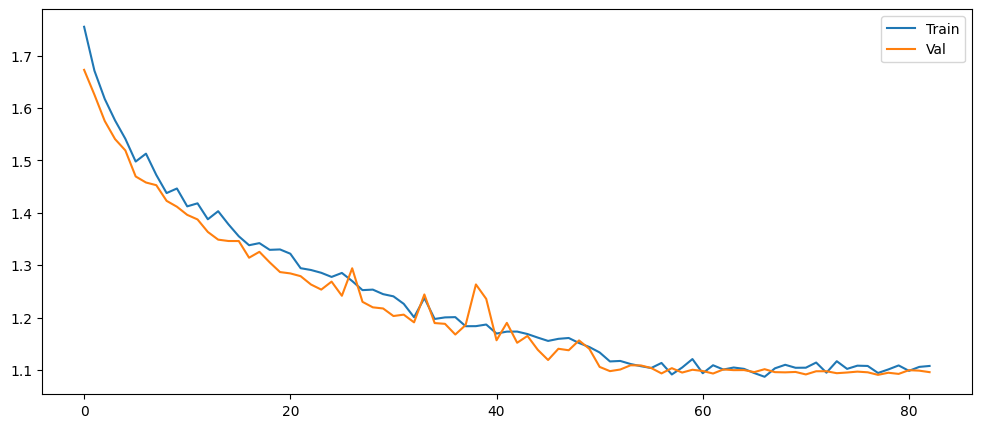

In [34]:
plt.figure(figsize=(12,5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png")
plt.show()

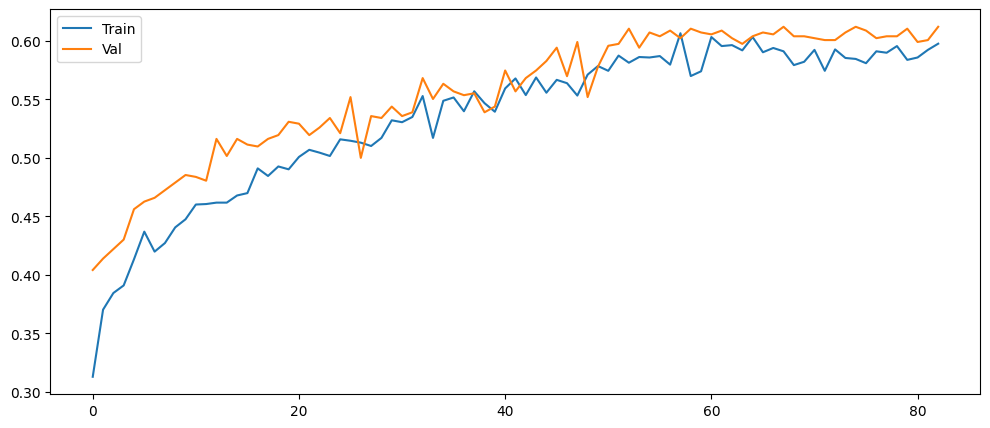

In [35]:
plt.figure(figsize=(12,5))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/acc_curve.png")
plt.show()

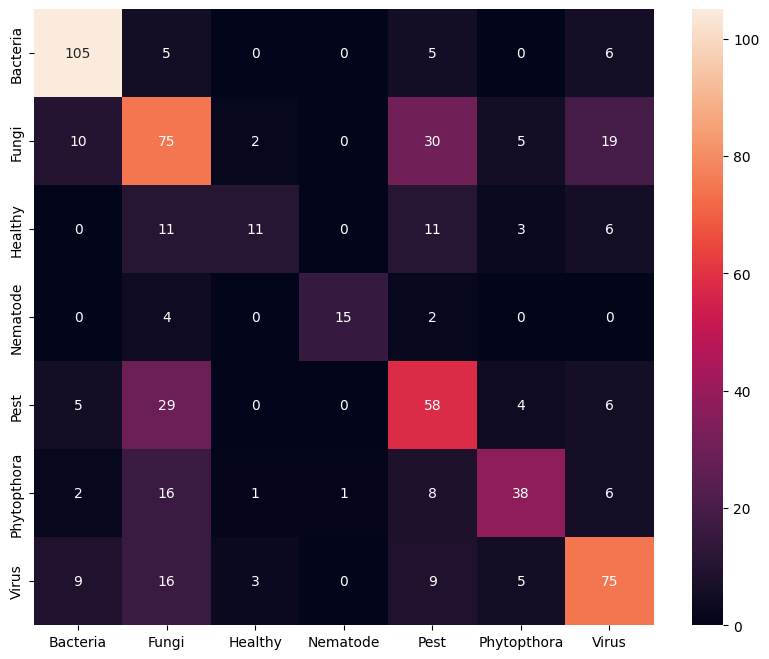

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png")
plt.show()